<a href="https://colab.research.google.com/github/Ebratul/Python/blob/main/Python%20/pytorch/Building_ANN(7).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/content/drive/MyDrive/fmnist_small - fmnist_small.csv')

In [3]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


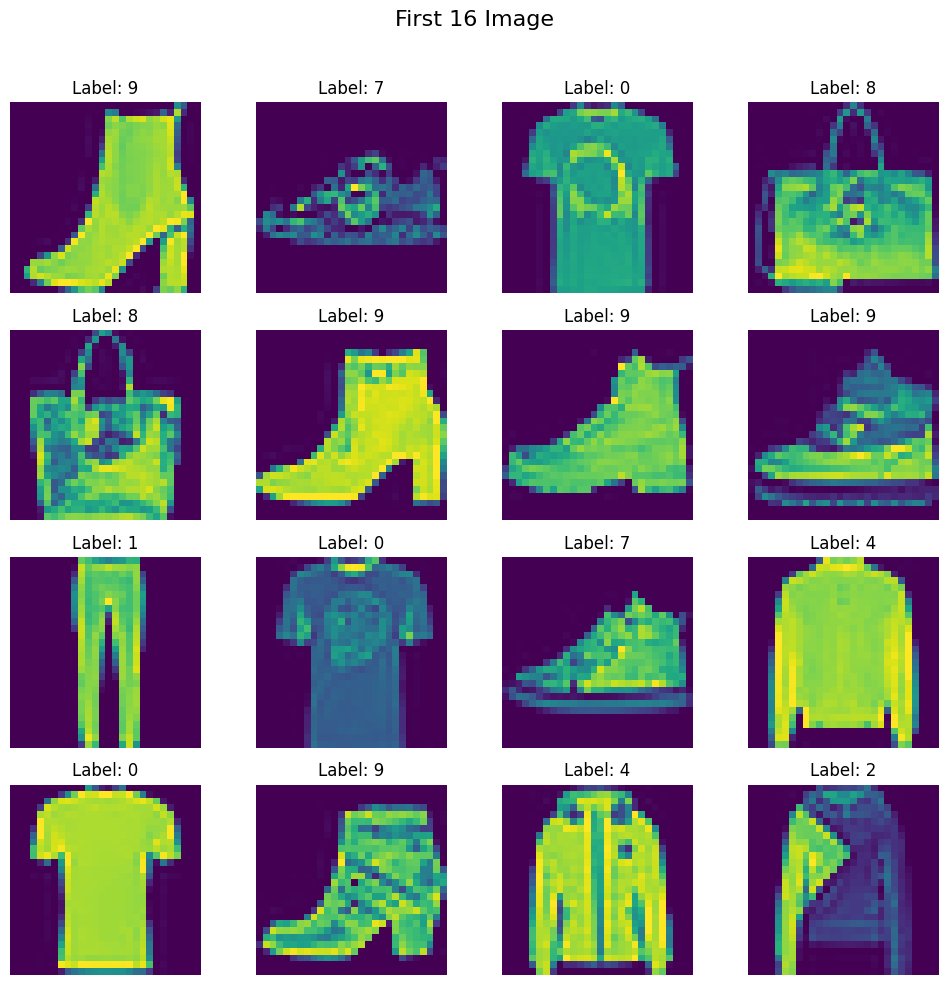

In [4]:
fig, axes = plt.subplots(4,4, figsize=(10,10))
fig.suptitle("First 16 Image", fontsize = 16)

for i, ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f"Label: {df.iloc[i,0]}")

plt.tight_layout(rect = [0, 0, 1, 0.96])
plt.show()

In [5]:
X = df.iloc[:,1:].values
y = df.iloc[:, 0].values

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [8]:
from torch.utils.data import Dataset, DataLoader

In [9]:
class CustomDataset(Dataset):
  def __init__(self, feature, label):

    self.feature = torch.tensor(feature, dtype = torch.float32)
    self.label = torch.tensor(label, dtype = torch.long)

  def __len__(self):
    return len(self.feature)

  def __getitem__(self, index):
    return self.feature[index], self.label[index]

In [10]:
train_dataset = CustomDataset(X_train, y_train)

In [11]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [12]:
test_dataset = CustomDataset(X_test, y_test)

In [13]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader  = DataLoader(test_dataset, batch_size = 32, shuffle = False)

In [14]:
class MyNN(nn.Module):

  def __init__(self, num_feature):

    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_feature, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )

  def forward(self, x):
    return self.model(x)

In [15]:
epoch = 100
learning_rate = 0.1

In [16]:
model = MyNN(X_train.shape[1])

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr = learning_rate)

In [18]:
for epoch in range(epoch):

  total_epoch_loss = 0
  for batch_feature, batch_label in train_loader:

    #forward pass
    output = model(batch_feature)

    #calculate loss
    loss = criterion(output, batch_label)

    #back pass
    optimizer.zero_grad()
    loss.backward()

    #update grads
    optimizer.step()

    total_epoch_loss += loss.item()

  print(f"Epoch: {epoch+1}, Loss: {total_epoch_loss/len(train_loader)}")

Epoch: 1, Loss: 0.004661594915475386
Epoch: 2, Loss: 0.005011930077259119
Epoch: 3, Loss: 0.006359317324046667
Epoch: 4, Loss: 0.005218423795110235
Epoch: 5, Loss: 0.1025596945375825
Epoch: 6, Loss: 0.026292578948972127
Epoch: 7, Loss: 0.0070359074440784755
Epoch: 8, Loss: 0.005181297448095089
Epoch: 9, Loss: 0.0071648628344216075
Epoch: 10, Loss: 0.00628711417230079
Epoch: 11, Loss: 0.17113916640014698
Epoch: 12, Loss: 0.036230465974270674
Epoch: 13, Loss: 0.01580430594253509
Epoch: 14, Loss: 0.008934066114597954
Epoch: 15, Loss: 0.0035419887259680156
Epoch: 16, Loss: 0.00276238427759381
Epoch: 17, Loss: 0.0026053769584783973
Epoch: 18, Loss: 0.0023493419979543737
Epoch: 19, Loss: 0.0020978845993522553
Epoch: 20, Loss: 0.0018221239200405155
Epoch: 21, Loss: 0.0016189587220045117
Epoch: 22, Loss: 0.0014073341451391267
Epoch: 23, Loss: 0.0014413571247132496
Epoch: 24, Loss: 0.0014483604355579396
Epoch: 25, Loss: 0.001290774732187856
Epoch: 26, Loss: 0.001193331221875269
Epoch: 27, Loss:

In [19]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [20]:
total = 0
correct = 0

with torch.no_grad():
  for batch_feature, batch_label in test_loader:
    output = model(batch_feature)
    _, predicted = torch.max(output.data, 1)
    total += batch_label.size(0)
    correct += (predicted == batch_label).sum().item()

  print(correct /  total)

0.8366666666666667
